In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor

# Cargar los datos correctamente
from google.colab import files
uploaded = files.upload()

# Intenta detectar delimitador automáticamente
try:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', low_memory=False)
except pd.errors.ParserError:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', sep=';', low_memory=False)

# Eliminar columna de índice innecesaria si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
# Vista previa del DataFrame
df.head()

Saving Anexo ET_demo_round_traces_2022.csv to Anexo ET_demo_round_traces_2022 (1).csv


,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,TimeAlive,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,de_inferno,Terrorist,1,4,1,False,True,False,False,51.120.248.995.704.500,...,0,0,0,0,750,4400,0,0,0,0
1,de_inferno,Terrorist,1,4,1,False,True,False,False,4.348.662.552.266.170,...,0,0,0,0,800,4400,0,0,0,0
2,de_inferno,Terrorist,1,4,1,False,True,False,False,3.735.469.847.054.540,...,0,0,0,0,1000,4400,0,0,0,0
3,de_inferno,Terrorist,1,4,1,False,True,False,False,4.767.886.136.441.470,...,0,0,0,0,850,4400,0,0,0,0
4,de_inferno,Terrorist,1,4,1,False,True,True,False,5.312.251.089.027.310,...,0,0,0,0,1000,4400,0,0,0,0


In [5]:
# Nombres correctos de las columnas
column_names = [
    'PlayerId', 'Map', 'Team', 'InternalTeamId', 'MatchId', 'RoundId', 'RoundWinner',
    'MatchWinner', 'Survived', 'AbnormalMatch', 'TimeAlive', 'TravelledDistance',
    'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown', 'PrimaryAssaultRifle',
    'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol', 'FirstKillTime',
    'RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills',
    'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue', 'MatchKills',
    'MatchFlankKills', 'MatchAssists', 'MatchHeadshots'
]



# Columnas a convertir
cols_to_numeric = [
    'TimeAlive', 'TravelledDistance', 'RoundAssists', 'RoundHeadshots',
    'RoundStartingEquipmentValue', 'RoundKills', 'MatchKills', 'TeamStartingEquipmentValue'
]

# Convertir columnas a numéricas
for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")

# Eliminar filas con nulos en variables clave
df = df.dropna(subset=['MatchKills', 'TeamStartingEquipmentValue'])

# Convertir 'Survived' a booleano si existe
if 'Survived' in df.columns:
    df['Survived'] = df['Survived'].astype(bool)


# Resumen estadístico
cols_to_describe = [col for col in cols_to_numeric if col in df.columns]
print("\nResumen estadístico:")
print(df[cols_to_describe].describe())



Resumen estadístico:
        TimeAlive  TravelledDistance  RoundAssists  RoundHeadshots  \
count  780.000000         281.000000  79157.000000    79157.000000   
mean   281.343109        1184.341988      0.146178        0.301553   
std    292.553701       12337.137578      0.385601        0.578843   
min      0.000000           0.000000      0.000000        0.000000   
25%     54.125000           0.000000      0.000000        0.000000   
50%    105.125000           0.000000      0.000000        0.000000   
75%    531.875000           0.000000      0.000000        0.000000   
max    990.625000      171008.000000      4.000000        5.000000   

       RoundStartingEquipmentValue    RoundKills    MatchKills  \
count                 79157.000000  79157.000000  79157.000000   
mean                   3778.108695      0.671349      8.511578   
std                    2111.285406      0.881798      6.195079   
min                       0.000000      0.000000      0.000000   
25%              

📊 MSE (Regresión múltiple): 57.9617

🔍 Coeficientes de cada variable:
TeamStartingEquipmentValue: -0.0005
RoundStartingEquipmentValue: 0.0015
TimeAlive: -0.2709
TravelledDistance: 0.0000

Intercepto: 5.2807


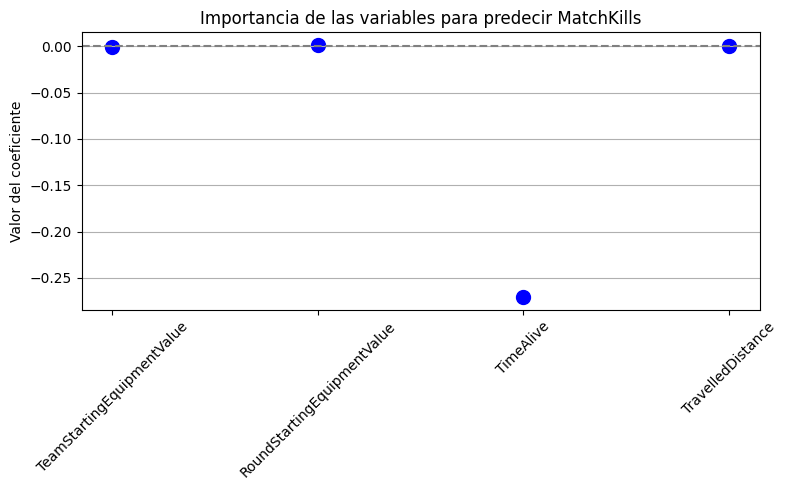

In [6]:
# Variables predictoras
features = [
    'TeamStartingEquipmentValue',
    'RoundStartingEquipmentValue',
    'TimeAlive',
    'TravelledDistance'
]

# Asegurarse de que las columnas sean numéricas
df[features + ['MatchKills']] = df[features + ['MatchKills']].apply(pd.to_numeric, errors='coerce')

# Eliminar filas con valores faltantes
df = df.dropna(subset=features + ['MatchKills'])

# Separar X e y
X = df[features]
y = df['MatchKills']

# Separar entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# Predecir
y_pred = lr_multi.predict(X_test)

# Mostrar evaluación
print("📊 MSE (Regresión múltiple):", round(mean_squared_error(y_test, y_pred), 4))
print("\n🔍 Coeficientes de cada variable:")
for feature, coef in zip(features, lr_multi.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"\nIntercepto: {lr_multi.intercept_:.4f}")


# Visualización de coeficientes con puntos
plt.figure(figsize=(8, 5))
plt.scatter(features, lr_multi.coef_, color='blue', s=100)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Importancia de las variables para predecir MatchKills')
plt.ylabel('Valor del coeficiente')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()